In [87]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd

%store -r datasets

In [88]:
df = datasets['lotacao_completo']
df = df.sort_values(by='cumprimento', axis=0, ascending=True, inplace=False, na_position='last', ignore_index=False)
df.head()

,servico,mes,regiao,passageiros_total,viagens_total,cumprimento,passageiros_por_viagem
7775,SP601,2023-10,Zona Oeste,3789,122,13.810000,31.057377
7018,922,2022-12,Zona Norte / Subúrbio,6130,158,14.408421,38.797468
2291,439,2023-01,Zona Sul,798,33,14.756667,24.181818
4466,709,2023-04,Zona Norte / Subúrbio,143,15,16.980000,9.533333
2738,485,2022-06,Zona Sul,130225,4449,17.043077,29.270623


<Figure size 640x480 with 0 Axes>

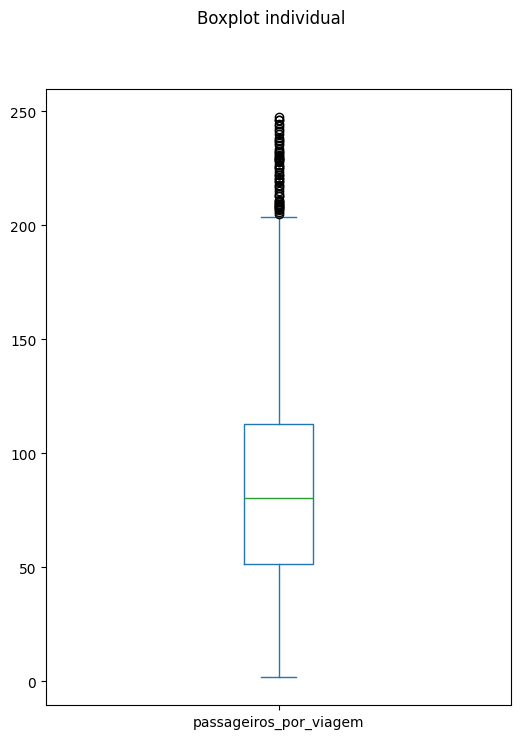

<Figure size 640x480 with 0 Axes>

In [89]:
df[['passageiros_por_viagem']].plot(kind='box', subplots=True, title="Boxplot individual", figsize=(6, 8))
plt.figure()

<Figure size 640x480 with 0 Axes>

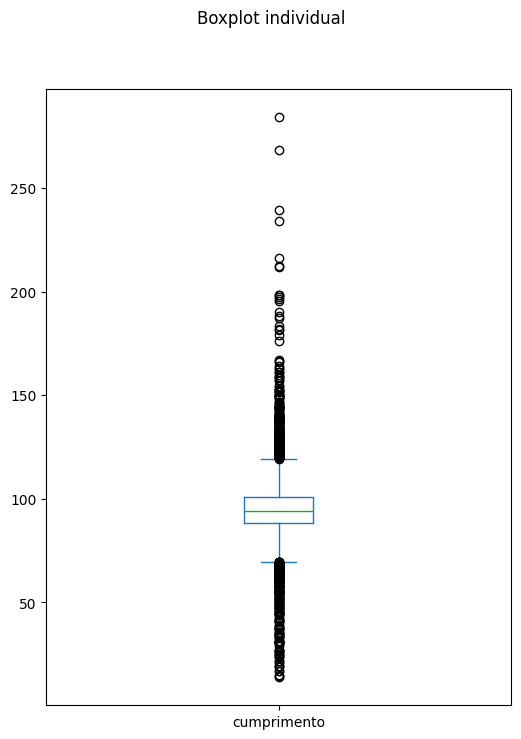

<Figure size 640x480 with 0 Axes>

In [90]:
df[['cumprimento']].plot(kind='box', subplots=True, title="Boxplot individual", figsize=(6, 8))
plt.figure()

<Figure size 640x480 with 0 Axes>

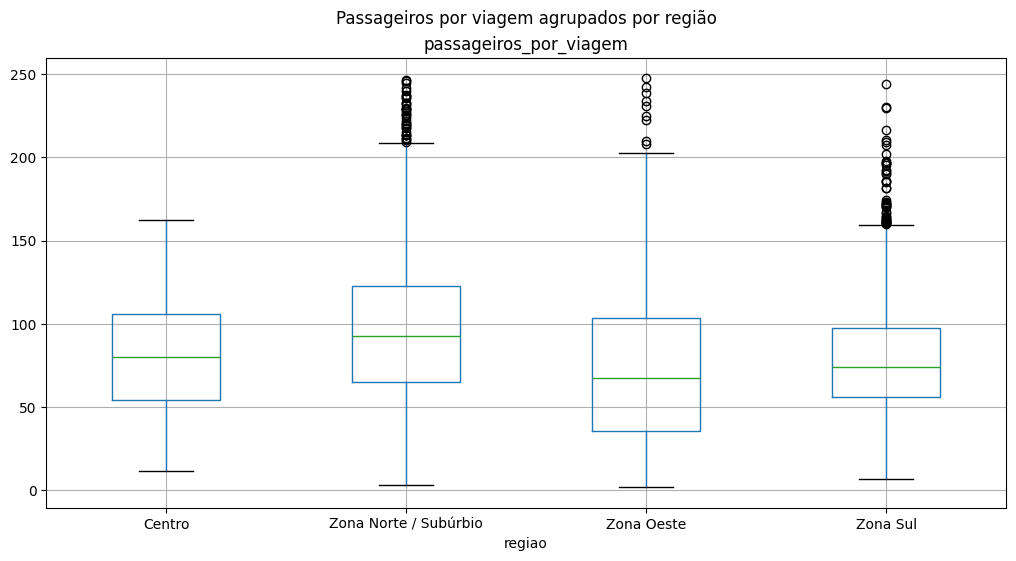

<Figure size 640x480 with 0 Axes>

In [91]:
df.boxplot(column='passageiros_por_viagem', by='regiao', figsize=(12, 6))
plt.suptitle('Passageiros por viagem agrupados por região')

plt.figure()

<Figure size 640x480 with 0 Axes>

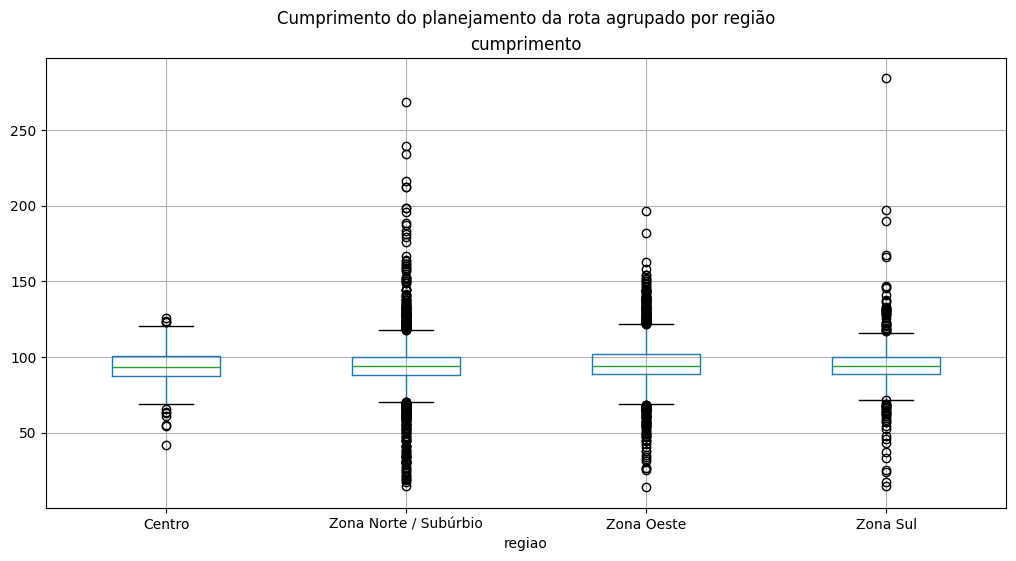

<Figure size 640x480 with 0 Axes>

In [92]:
df.boxplot(column='cumprimento', by='regiao', figsize=(12, 6))
plt.suptitle('Cumprimento do planejamento da rota agrupado por região')
plt.figure()

<Figure size 640x480 with 0 Axes>

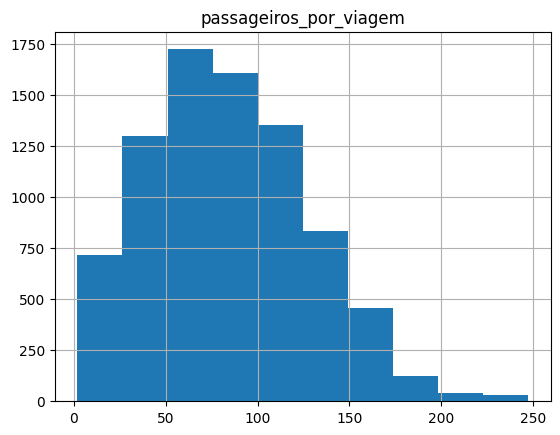

<Figure size 640x480 with 0 Axes>

In [93]:
df[['passageiros_por_viagem']].hist()
plt.figure()

<Figure size 640x480 with 0 Axes>

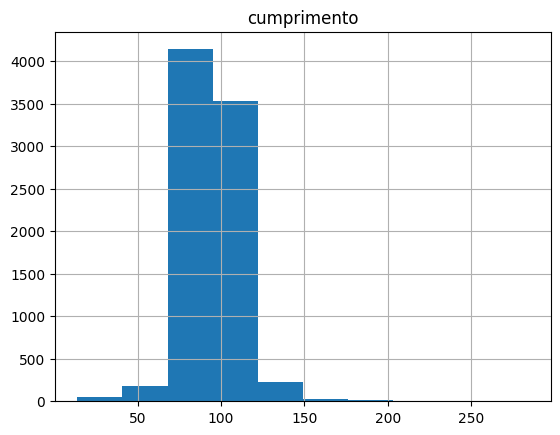

<Figure size 640x480 with 0 Axes>

In [94]:
df[['cumprimento']].hist()
plt.figure()

<Figure size 640x480 with 0 Axes>

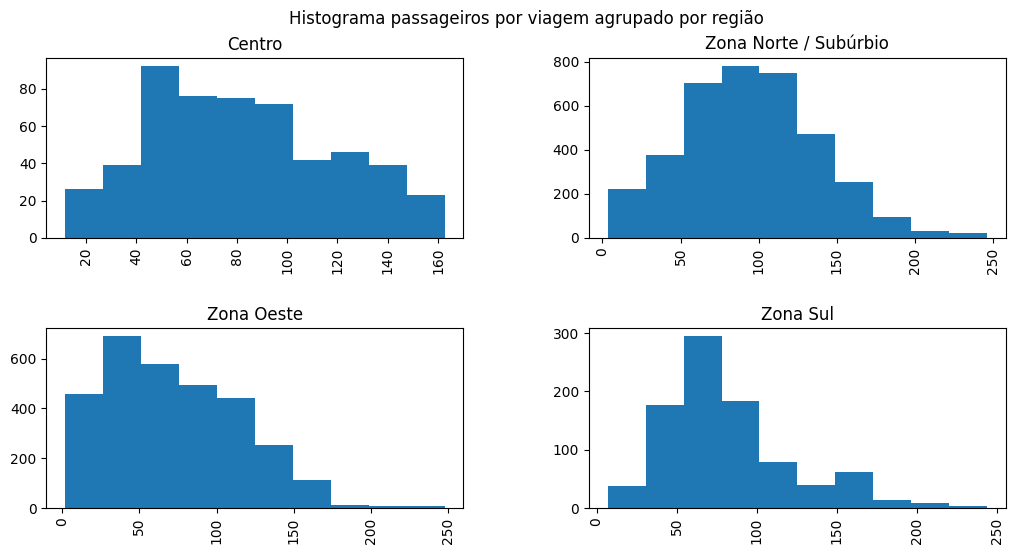

<Figure size 640x480 with 0 Axes>

In [95]:
df.hist(column='passageiros_por_viagem', by='regiao', figsize=(12, 6))
plt.suptitle('Histograma passageiros por viagem agrupado por região')
plt.figure()

<Figure size 640x480 with 0 Axes>

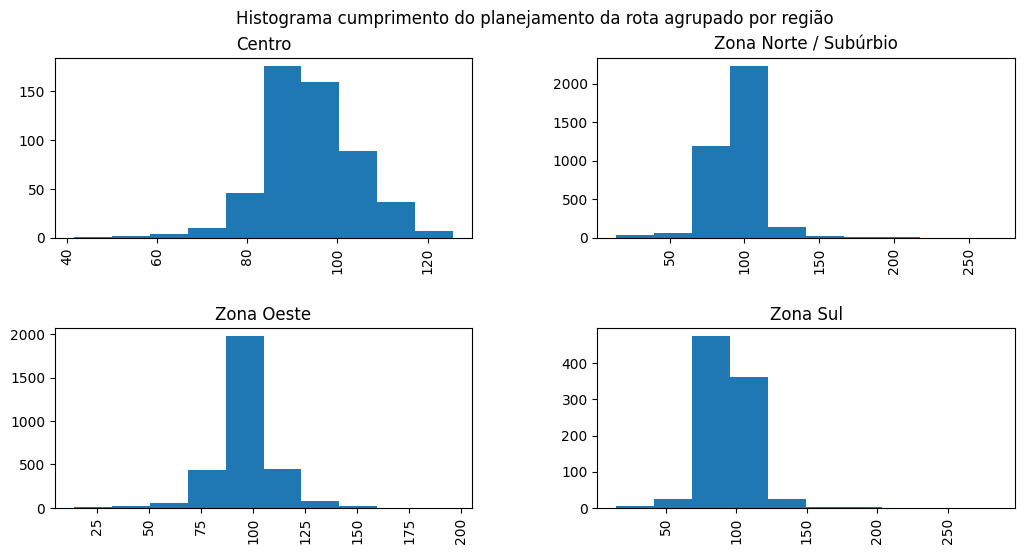

<Figure size 640x480 with 0 Axes>

In [96]:
df.hist(column='cumprimento', by='regiao', figsize=(12, 6))
plt.suptitle('Histograma cumprimento do planejamento da rota agrupado por região')
plt.figure()

<Figure size 640x480 with 0 Axes>

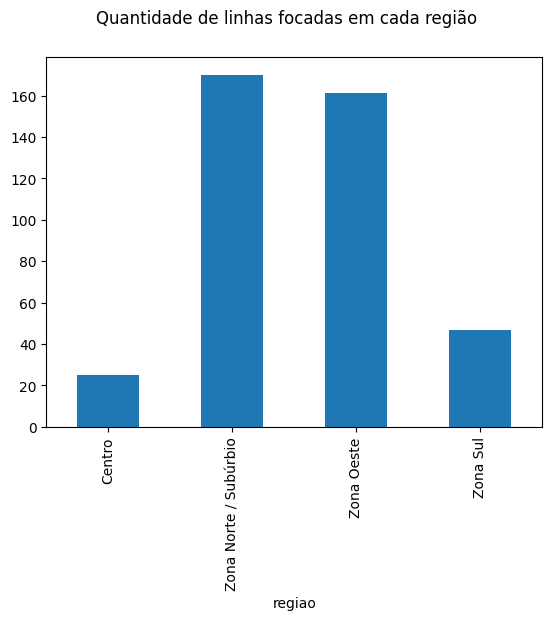

<Figure size 640x480 with 0 Axes>

In [97]:
df.groupby('regiao')['servico'].nunique().plot(kind='bar')
plt.suptitle('Quantidade de linhas focadas em cada região')
plt.figure()

Text(0.5, 1.0, 'Dispersão de passageiros e viagens totais de cada linha')

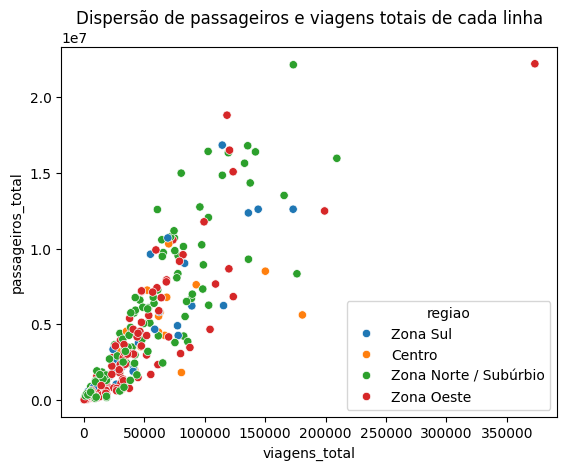

In [98]:
df_agrupado = df[['regiao', 'servico', 'passageiros_total', 'viagens_total']].groupby(['servico', 'regiao'])[['passageiros_total', 'viagens_total']].sum()
sns.scatterplot(x='viagens_total', y='passageiros_total', hue='regiao', data=df_agrupado)
plt.title('Dispersão de passageiros e viagens totais de cada linha')

In [99]:
df[['viagens_total', 'passageiros_total', 'passageiros_por_viagem', 'cumprimento']].corr()

,viagens_total,passageiros_total,passageiros_por_viagem,cumprimento
viagens_total,1.000000,0.842529,0.132797,0.081910
passageiros_total,0.842529,1.000000,0.497010,0.022349
passageiros_por_viagem,0.132797,0.497010,1.000000,-0.083996
cumprimento,0.081910,0.022349,-0.083996,1.000000


In [100]:
df_ids = datasets['ids_por_bairro_rj']
df_linha_bairro = datasets['matriz_linha_bairro']

gdf_bairros = gpd.read_file('../dados/Limite_de_Bairros.geojson').rename(columns={'nome': 'bairro'}).astype(str)
df_linha_bairro_com_cod = df_linha_bairro.merge(gdf_bairros[['bairro', 'codbairro']], on='bairro').astype(str)
df_linha_bairro_com_cod['codbairro'] = df_linha_bairro_com_cod['codbairro'].astype(int)
df_ids['codbairro'] = df_ids['codbairro'].astype(int)
df_linha_bairro_ids = df_linha_bairro_com_cod.merge(df_ids[['codbairro', 'ids']], on='codbairro')
df_linha_bairro_ids = df_linha_bairro_ids.groupby('bairro').agg({
    'codbairro': 'first',
    'ids': 'first',
    'regiao': 'first',
    'linha': 'nunique' 
}).rename(columns={'linha': 'qtd_linhas'}).reset_index()
df_linha_bairro_ids.head(157)


,bairro,codbairro,ids,regiao,qtd_linhas
0,Abolição,70,0.613303,Zona Norte / Subúrbio,24
1,Acari,111,0.512086,Zona Norte / Subúrbio,34
2,Alto da Boa Vista,34,0.524369,Zona Norte / Subúrbio,5
3,Anchieta,107,0.554227,Zona Oeste,19
4,Andaraí,37,0.644252,Zona Norte / Subúrbio,15
...,...,...,...,...,...
152,Vila Valqueire,125,0.635159,Zona Oeste,23
153,Vila da Penha,74,0.640781,Zona Norte / Subúrbio,18
154,Vista Alegre,75,0.620438,Zona Norte / Subúrbio,12
155,Zumbi,92,0.660360,Zona Norte / Subúrbio,9


Text(0.5, 1.0, 'Dispersão de ids e nº de linhas que passam em um bairro')

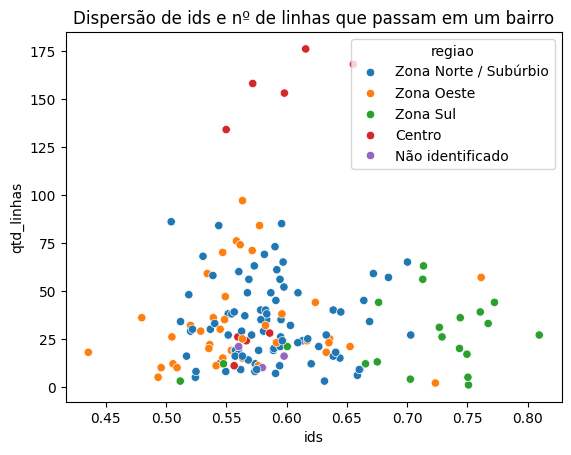

In [101]:
sns.scatterplot(x='ids', y='qtd_linhas', hue='regiao', data=df_linha_bairro_ids)
plt.title('Dispersão de ids e nº de linhas que passam em um bairro')

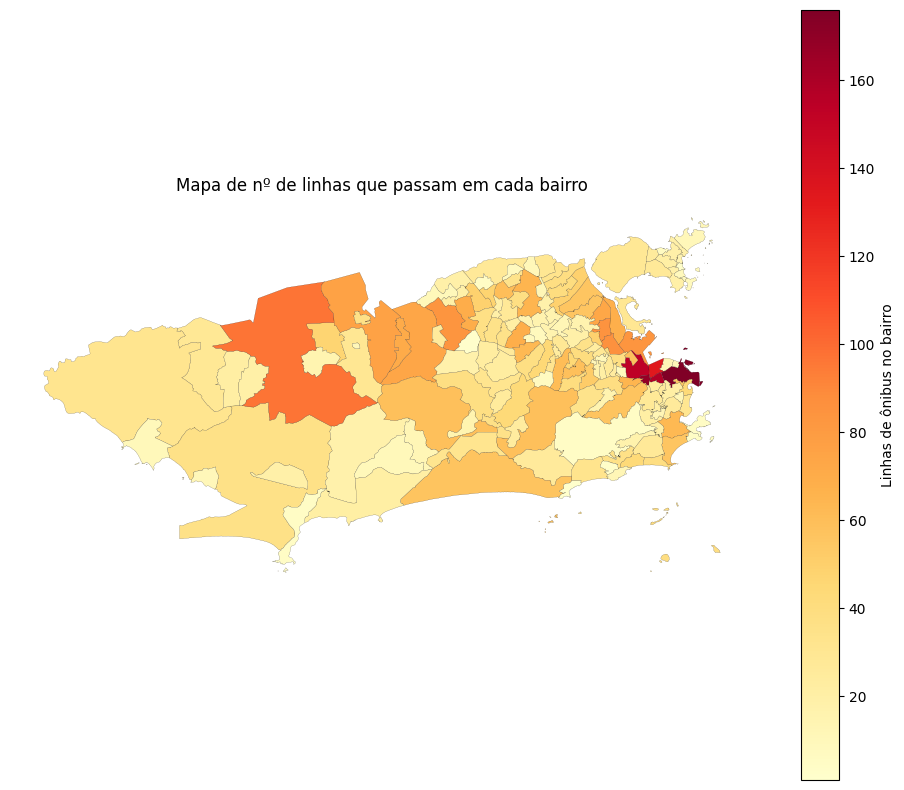

In [102]:
contagem_linhas = datasets['matriz_linha_bairro'].groupby('bairro')['linha'].nunique().reset_index()
contagem_linhas = contagem_linhas.rename(columns={'linha': 'quantidade_linhas'})

gdf_bairros = gpd.read_file('../dados/Limite_de_Bairros.geojson')
mapa_linhas = gdf_bairros.merge(contagem_linhas, left_on='nome', right_on='bairro', how='left')

mapa_linhas['quantidade_linhas'] = mapa_linhas['quantidade_linhas']
mapa_linhas = gpd.GeoDataFrame(mapa_linhas, geometry='geometry')
mapa_linhas = mapa_linhas.to_crs(4326)

mapa_linhas.plot(column='quantidade_linhas', cmap='YlOrRd', linewidth=0.1, edgecolor='black', legend=True, legend_kwds={'label': "Linhas de ônibus no bairro", 'orientation': "vertical"}, figsize=(12, 10)).set_axis_off()
plt.title('Mapa de nº de linhas que passam em cada bairro')

mapa_interativo = mapa_linhas.explore(
    column='quantidade_linhas',
    cmap='YlOrRd',
    tooltip=['bairro', 'quantidade_linhas'], 
    legend_name='Total de Linhas',
    tiles='CartoDB positron'
)




In [103]:
#Teste de mapa
mapa_interativo.save("../dados/mapa_interativo.html")

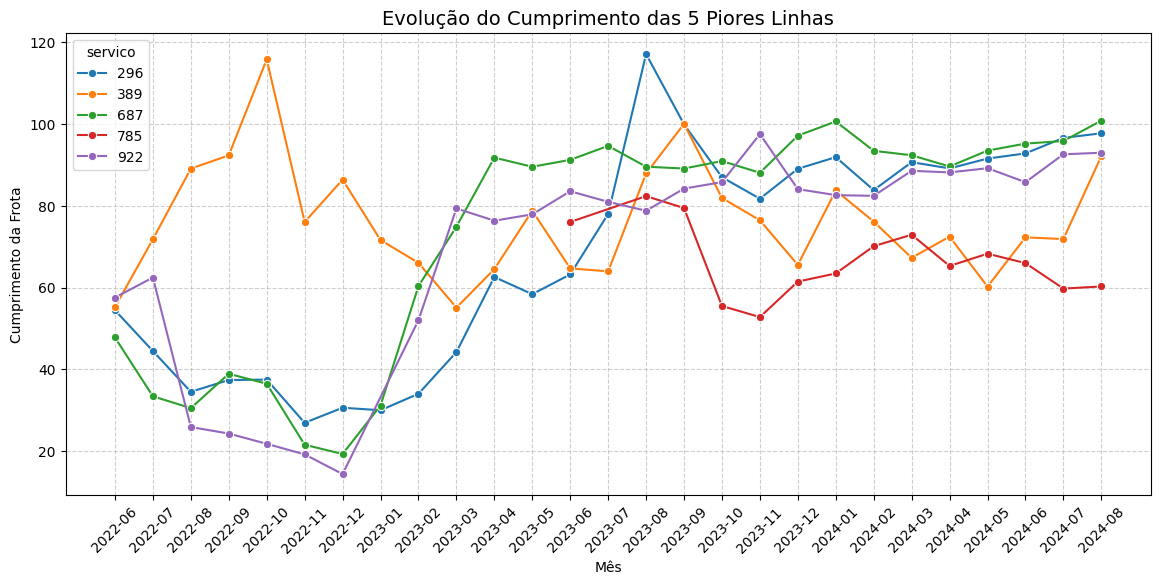

In [104]:
top_5_piores = datasets['ranking']['servico'].head(5).tolist()
df_piores = datasets['lotacao_completo'][datasets['lotacao_completo']['servico'].isin(top_5_piores)]
df_piores['mes_str'] = df_piores['mes'].astype(str)
plt.figure(figsize=(14, 6))
sns.lineplot(data=df_piores, x='mes_str', y='cumprimento', hue='servico', marker='o')
plt.title('Evolução do Cumprimento das 5 Piores Linhas', fontsize=14)
plt.xticks(rotation=45)
plt.ylabel('Cumprimento da Frota')
plt.xlabel('Mês')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

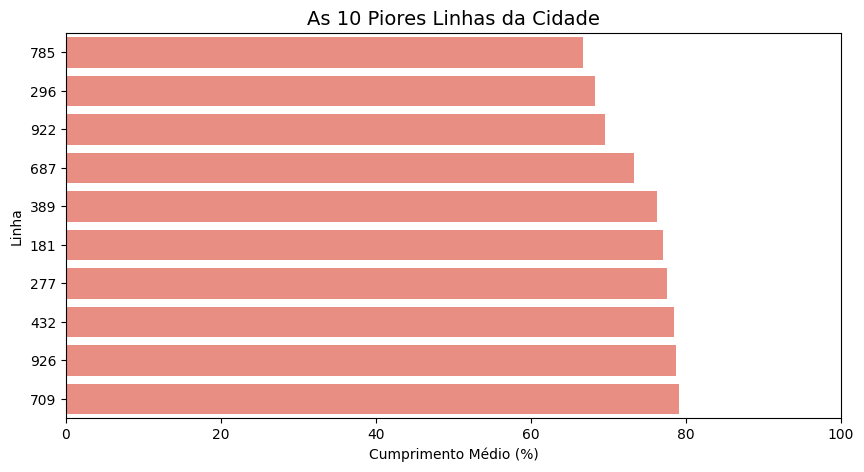

In [105]:
top_10 = datasets['ranking'].head(10)
plt.figure(figsize=(10, 5))
sns.barplot(data=top_10, x='cumprimento_medio', y='servico', color='salmon')
plt.title('As 10 Piores Linhas da Cidade', fontsize=14)
plt.xlabel('Cumprimento Médio (%)')
plt.ylabel('Linha')
plt.xlim(0, 100) 
plt.show()

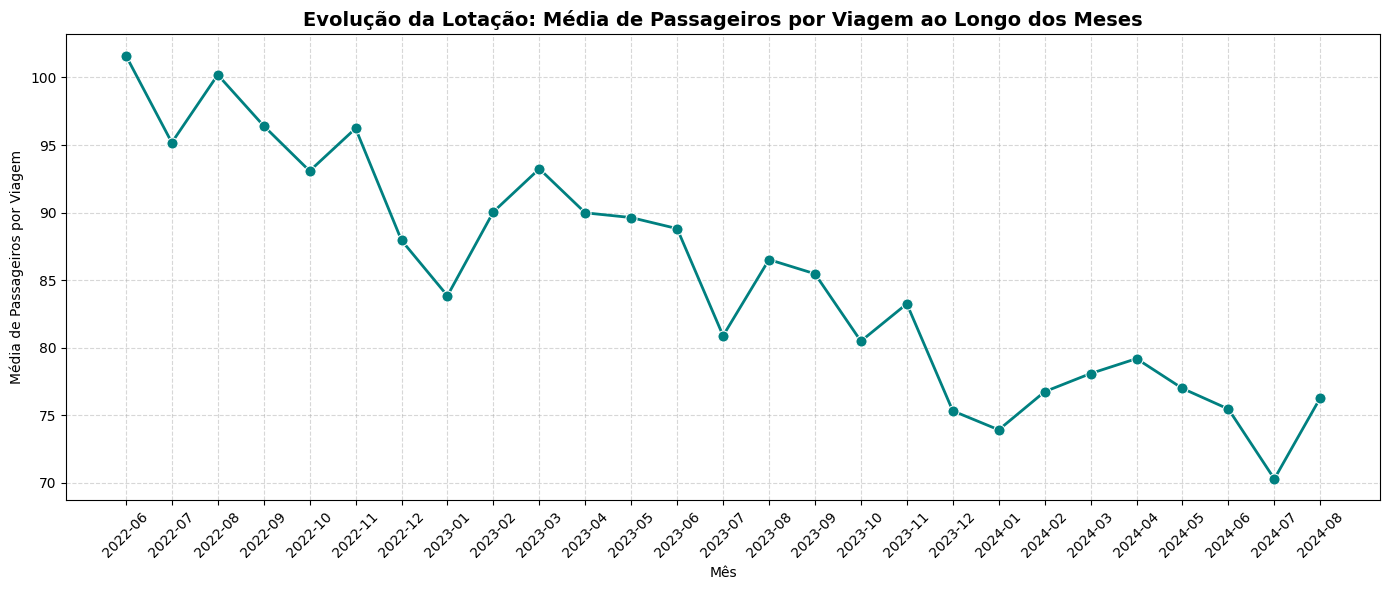

In [106]:
df_evolucao_lota = datasets['lotacao_completo'].groupby('mes')['passageiros_por_viagem'].mean().reset_index()
df_evolucao_lota['mes_str']=df_evolucao_lota['mes'].astype(str)
plt.figure(figsize=(14, 6))
sns.lineplot(data=df_evolucao_lota, x='mes_str', y='passageiros_por_viagem', marker='o', color='teal', linewidth=2,markersize=8)
plt.title('Evolução da Lotação: Média de Passageiros por Viagem ao Longo dos Meses', fontsize=14, weight='bold')
plt.xlabel('Mês')
plt.ylabel('Média de Passageiros por Viagem')
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


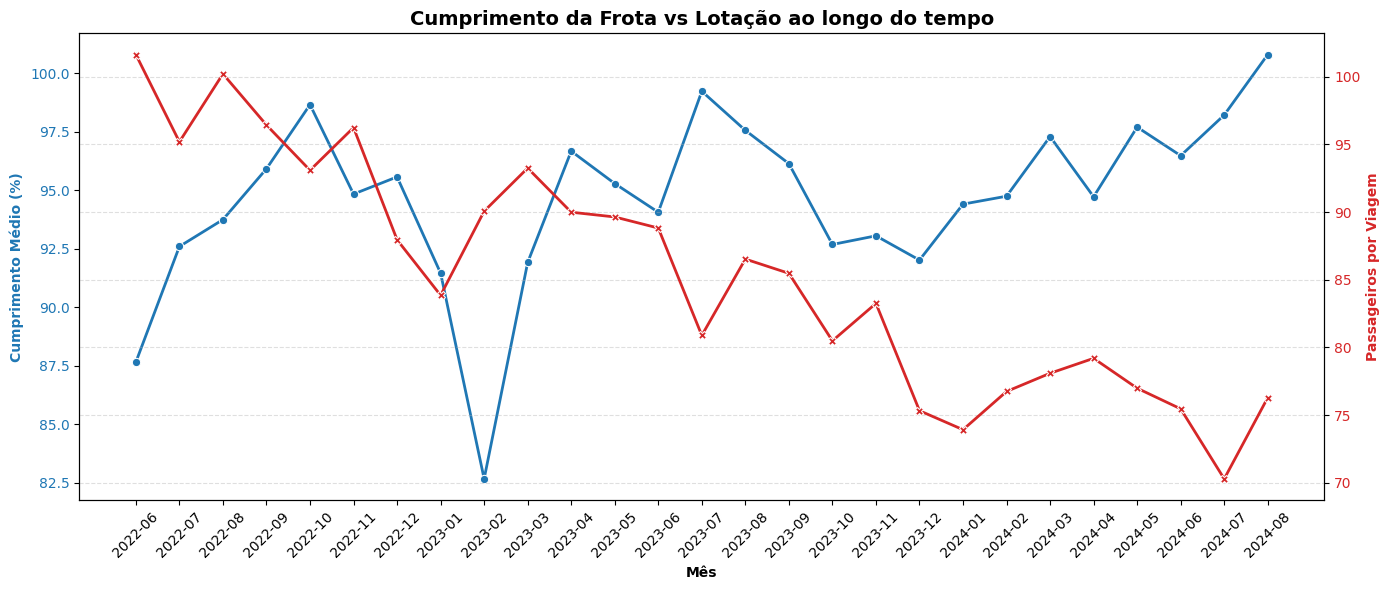

In [107]:
df_tempo = datasets['lotacao_completo'].groupby('mes').agg({'cumprimento':'mean','passageiros_por_viagem':'mean'}).reset_index()
df_tempo['mes_str']=df_tempo['mes'].astype(str)
fig, ax1=plt.subplots(figsize=(14, 6))
color='tab:blue'
ax1.set_xlabel('Mês', weight='bold')
ax1.set_ylabel('Cumprimento Médio (%)', color=color, weight='bold')
sns.lineplot(data=df_tempo, x='mes_str', y='cumprimento', marker='o', color=color, ax=ax1, linewidth=2)
ax1.tick_params(axis='y', labelcolor=color)
ax1.tick_params(axis='x', rotation=45)
ax2 = ax1.twinx() 
color='tab:red'
ax2.set_ylabel('Passageiros por Viagem', color=color, weight='bold')
sns.lineplot(data=df_tempo, x='mes_str', y='passageiros_por_viagem', marker='X', color=color, ax=ax2, linewidth=2)
ax2.tick_params(axis='y', labelcolor=color)
plt.title('Cumprimento da Frota vs Lotação ao longo do tempo', fontsize=14, weight='bold')
plt.grid(True, linestyle='--', alpha=0.4)
fig.tight_layout()
plt.show()